In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import missingno as msno
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.2f}'.format)

print("Libraries loaded ✓")


Libraries loaded ✓


## 1. Data Loading & Profiling

In [2]:
# Load raw data
df_raw = pd.read_csv('brfss_survey_data_2024.csv')
print(f"Shape: {df_raw.shape}")
print(f"Memory usage: {df_raw.memory_usage(deep=True).sum() / 1e6:.1f} MB")
df_raw.head(3)


Shape: (457670, 301)
Memory usage: 1120.8 MB


,_STATE,FMONTH,IDATE,IMONTH,IDAY,IYEAR,DISPCODE,SEQNO,_PSU,CTELENM1,PVTRESD1,COLGHOUS,STATERE1,CELPHON1,LADULT1,...,_PACKDAY,_PACKYRS,_LCSYQTS,_LCSSMKG,_LCSELIG,_LCSCTSN,_LCSPSTF,DRNKANY6,DROCDY4_,_RFBING6,_DRNKWK3,_RFDRHV9,_FLSHOT7,_PNEUMO3,_AIDTST4
0,1.00,2.00,b'02282024',b'02',b'28',b'2024',1100.00,b'2024000001',2024000001.00,1.00,1.00,NaN,1.00,2.00,1.00,...,NaN,NaN,NaN,6.00,2.00,NaN,9.00,2.00,0.00,1.00,0.00,1.00,1.00,2.00,2.00
1,1.00,2.00,b'02212024',b'02',b'21',b'2024',1100.00,b'2024000002',2024000002.00,1.00,1.00,NaN,1.00,2.00,1.00,...,100.00,2.00,53.00,5.00,2.00,4.00,9.00,2.00,0.00,1.00,0.00,1.00,1.00,1.00,2.00
2,1.00,2.00,b'02212024',b'02',b'21',b'2024',1100.00,b'2024000003',2024000003.00,1.00,1.00,NaN,1.00,2.00,1.00,...,75.00,34.00,NaN,1.00,1.00,4.00,2.00,1.00,100.00,2.00,1400.00,1.00,NaN,NaN,2.00


In [3]:
# Data types summary
dtype_counts = df_raw.dtypes.value_counts()
print("Dtype distribution:")
print(dtype_counts)


Dtype distribution:
float64    296
str          5
Name: count, dtype: int64


In [4]:
# Missing value profiling
miss = df_raw.isnull().sum()
miss_pct = (miss / len(df_raw) * 100).round(2)
miss_df = pd.DataFrame({'missing_count': miss, 'missing_pct': miss_pct})
miss_df = miss_df[miss_df['missing_count'] > 0].sort_values('missing_pct', ascending=False)

print(f"Columns with any missing: {len(miss_df)} / {df_raw.shape[1]}")
print(f"Columns with >50% missing: {(miss_df.missing_pct > 50).sum()}")
print(f"Columns with >80% missing: {(miss_df.missing_pct > 80).sum()}")
print(f"Completely empty columns: {(miss_df.missing_pct == 100).sum()}")
miss_df.head(20)


Columns with any missing: 249 / 301
Columns with >50% missing: 170
Columns with >80% missing: 109
Completely empty columns: 3


,missing_count,missing_pct
COLGHOUS,457656,100.00
RCSGEND1,457670,100.00
RCSXBRTH,457670,100.00
CSRVCTL2,457088,99.87
ICFQSTVR,456931,99.84
CCLGHOUS,456244,99.69
HPVDSHT,455650,99.56
CSRVINST,455045,99.43
NOBCUSE8,454899,99.39
LASTSIG4,454443,99.29


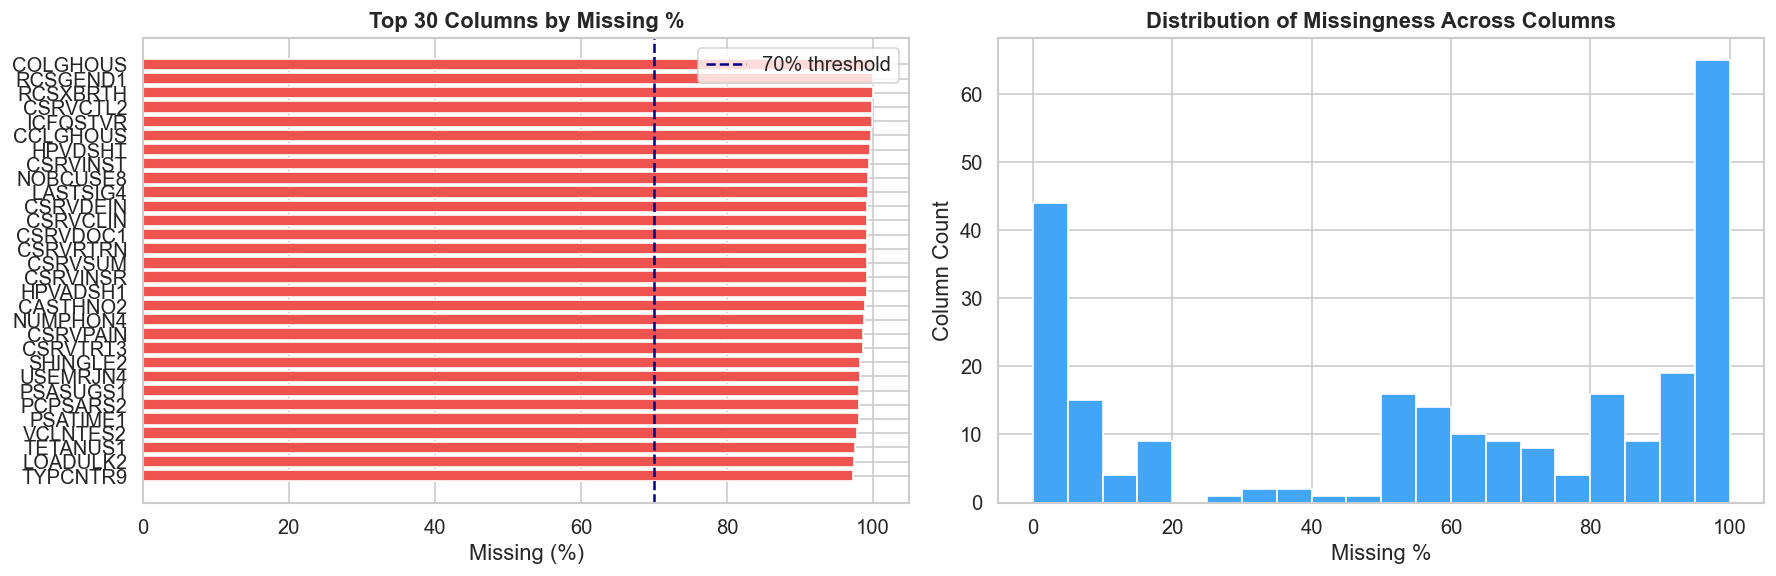

In [5]:
# Missingno matrix — visualize sparsity pattern (sample 500 rows for speed)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Bar chart of top 30 missing columns
top_miss = miss_df.head(30)
axes[0].barh(top_miss.index[::-1], top_miss['missing_pct'][::-1], color='#EF5350')
axes[0].set_title('Top 30 Columns by Missing %', fontweight='bold')
axes[0].set_xlabel('Missing (%)')
axes[0].axvline(70, color='navy', ls='--', lw=1.5, label='70% threshold')
axes[0].legend()

# Distribution of missingness
axes[1].hist(miss_df['missing_pct'], bins=20, color='#42A5F5', edgecolor='white')
axes[1].set_title('Distribution of Missingness Across Columns', fontweight='bold')
axes[1].set_xlabel('Missing %')
axes[1].set_ylabel('Column Count')

plt.tight_layout()
plt.show()


## 2. Data Cleaning & Imputation Strategy

In [6]:
# ── STEP 1: Drop columns with >70% missing ──────────────────────────────
miss_pct_all = df_raw.isnull().sum() / len(df_raw)
drop_cols = miss_pct_all[miss_pct_all > 0.70].index.tolist()
df = df_raw.drop(columns=drop_cols)
print(f"Dropped {len(drop_cols)} columns (>70% missing)")
print(f"Shape after drop: {df.shape}")


Dropped 121 columns (>70% missing)
Shape after drop: (457670, 180)


In [7]:
# ── STEP 2: Select core health variables ────────────────────────────────
CORE = ['GENHLTH','PHYSHLTH','MENTHLTH','POORHLTH',
        '_BMI5','_BMI5CAT','SEXVAR','_AGE_G','_AGE65YR',
        '_EDUCAG','_INCOMG1','EMPLOY1','MARITAL',
        'EXERANY2','SMOKE100','SMOKDAY2','ALCDAY4','AVEDRNK4',
        'CVDINFR4','CVDCRHD4','CVDSTRK3','ASTHMA3','CHCCOPD3',
        'ADDEPEV3','CHCKDNY2','HAVARTH4','DIABETE4',
        '_RFHLTH','_TOTINDA','_RFSMOK3','_RFBING6',
        '_STATE','IMONTH','IYEAR']

CORE = [c for c in CORE if c in df.columns]
df_core = df[CORE].copy()
print(f"Core variables selected: {len(CORE)}")


Core variables selected: 34


In [8]:
# ── STEP 3: Recode BRFSS sentinel values as NaN ─────────────────────────
# BRFSS uses 7/9 (don't know/refused) and 77/88/99 as sentinels
def brfss_nan(series):
    s = series.copy()
    if s.dtype in [np.float64, np.int64]:
        mx = s.max()
        if mx <= 9:
            s = s.replace([7.0, 9.0], np.nan)
        elif mx <= 99:
            s = s.replace([77.0, 88.0, 99.0], np.nan)
    return s

skip_cols = {'_STATE','IMONTH','IYEAR','_BMI5','_BMI5CAT','AVEDRNK4','ALCDAY4',
             '_EDUCAG','_INCOMG1','_AGE_G','_AGE65YR','SEXVAR'}

for col in df_core.columns:
    if col not in skip_cols:
        df_core[col] = brfss_nan(df_core[col])

print("Sentinel values recoded to NaN ✓")
print(f"Missing after sentinel recoding: {df_core.isnull().sum().sum():,}")


Sentinel values recoded to NaN ✓
Missing after sentinel recoding: 1,849,202


In [9]:
# ── STEP 4: Imputation ───────────────────────────────────────────────────
# Numeric: median | Categorical/object: mode

num_cols = df_core.select_dtypes(include=[np.number]).columns.tolist()
obj_cols = df_core.select_dtypes(include=['object']).columns.tolist()

for col in num_cols:
    if df_core[col].isnull().sum() > 0:
        df_core[col].fillna(df_core[col].median(), inplace=True)

for col in obj_cols:
    if df_core[col].isnull().sum() > 0:
        df_core[col].fillna(df_core[col].mode()[0], inplace=True)

print(f"Remaining nulls after imputation: {df_core.isnull().sum().sum()}")


Remaining nulls after imputation: 1849202


In [10]:
# ── STEP 5: Create readable label columns ────────────────────────────────
df_core['GENHLTH_LABEL'] = df_core['GENHLTH'].map({1:'Excellent',2:'Very good',3:'Good',4:'Fair',5:'Poor'})
df_core['SEX_LABEL'] = df_core['SEXVAR'].map({1:'Male',2:'Female'})
df_core['AGE_LABEL'] = df_core['_AGE_G'].map({
    1:'18-24',2:'25-29',3:'30-34',4:'35-39',5:'40-44',
    6:'45-49',7:'50-54',8:'55-59',9:'60-64',10:'65-69',
    11:'70-74',12:'75-79',13:'80+'})
df_core['EDU_LABEL'] = df_core['_EDUCAG'].map({1:'<HS',2:'HS grad',3:'Some college',4:'College grad'})
df_core['BMI_CAT_LABEL'] = df_core['_BMI5CAT'].map({1:'Underweight',2:'Normal',3:'Overweight',4:'Obese'})
df_core['BMI'] = df_core['_BMI5'] / 100
df_core['INCOME_LABEL'] = df_core['_INCOMG1'].map({
    1:'<$15K',2:'$15-25K',3:'$25-35K',4:'$35-50K',
    5:'$50-75K',6:'$75-100K',7:'$100-200K',8:'>$200K'})

print("Cleaned shape:", df_core.shape)
df_core.head(3)


Cleaned shape: (457670, 41)


,GENHLTH,PHYSHLTH,MENTHLTH,POORHLTH,_BMI5,_BMI5CAT,SEXVAR,_AGE_G,_AGE65YR,_EDUCAG,_INCOMG1,EMPLOY1,MARITAL,EXERANY2,SMOKE100,...,DIABETE4,_RFHLTH,_TOTINDA,_RFSMOK3,_RFBING6,_STATE,IMONTH,IYEAR,GENHLTH_LABEL,SEX_LABEL,AGE_LABEL,EDU_LABEL,BMI_CAT_LABEL,BMI,INCOME_LABEL
0,3.00,2.00,NaN,NaN,2249.00,2.00,2.00,6.00,2.00,2.00,9.00,NaN,3.00,1.00,2.00,...,3.00,1.00,1.00,1.00,1.00,1.00,b'02',b'2024',Good,Female,45-49,HS grad,Normal,22.49,NaN
1,1.00,NaN,NaN,NaN,2583.00,3.00,1.00,6.00,2.00,4.00,7.00,NaN,1.00,1.00,1.00,...,3.00,1.00,1.00,1.00,1.00,1.00,b'02',b'2024',Excellent,Male,45-49,College grad,Overweight,25.83,$100-200K
2,2.00,30.00,NaN,1.00,2253.00,2.00,1.00,5.00,1.00,3.00,9.00,1.00,6.00,1.00,1.00,...,3.00,1.00,1.00,2.00,2.00,1.00,b'02',b'2024',Very good,Male,40-44,Some college,Normal,22.53,NaN


## 3. Univariate Analysis

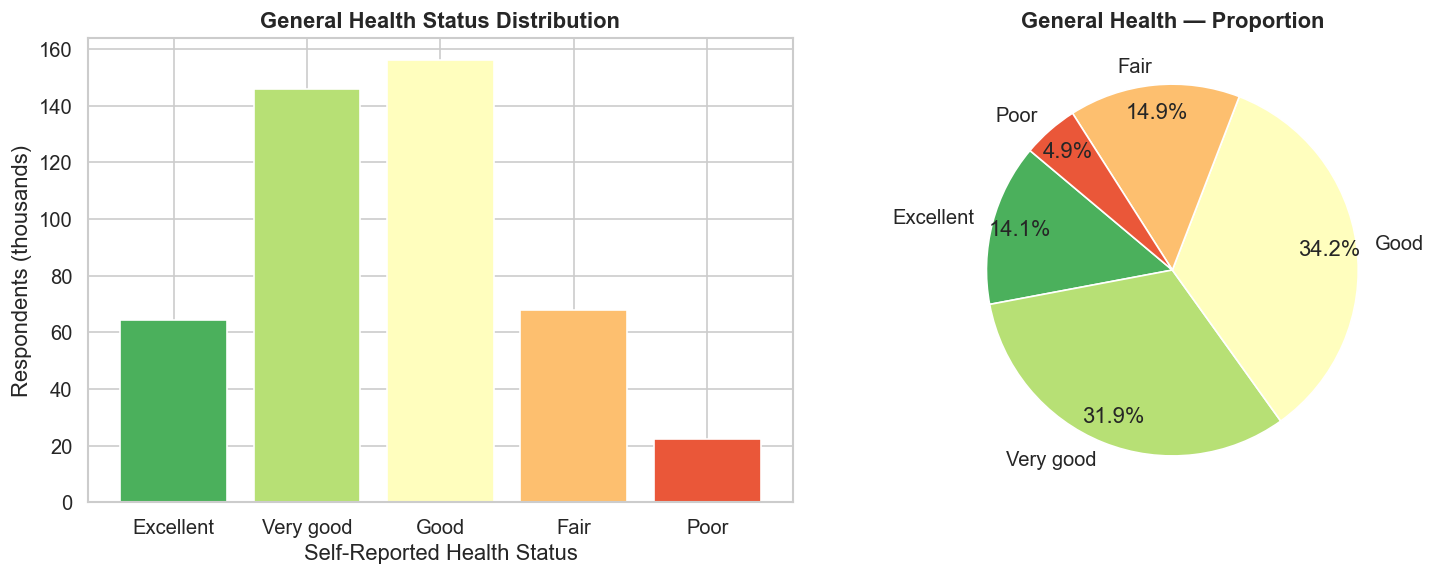

Good+ health: 80.3%
Fair/Poor: 19.7%


In [11]:
# General Health Status Distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

order = ['Excellent','Very good','Good','Fair','Poor']
counts = df_core['GENHLTH_LABEL'].value_counts().reindex(order).dropna()
colors_gh = sns.color_palette('RdYlGn_r', len(counts))

axes[0].bar(counts.index, counts.values / 1000, color=colors_gh, edgecolor='white')
axes[0].set_title('General Health Status Distribution', fontweight='bold')
axes[0].set_ylabel('Respondents (thousands)')
axes[0].set_xlabel('Self-Reported Health Status')

# Pie chart
axes[1].pie(counts.values, labels=counts.index, colors=colors_gh,
            autopct='%1.1f%%', startangle=140, pctdistance=0.85)
axes[1].set_title('General Health — Proportion', fontweight='bold')

plt.tight_layout()
plt.show()
print(f"Good+ health: {(counts[:3].sum()/counts.sum()*100):.1f}%")
print(f"Fair/Poor: {(counts[3:].sum()/counts.sum()*100):.1f}%")


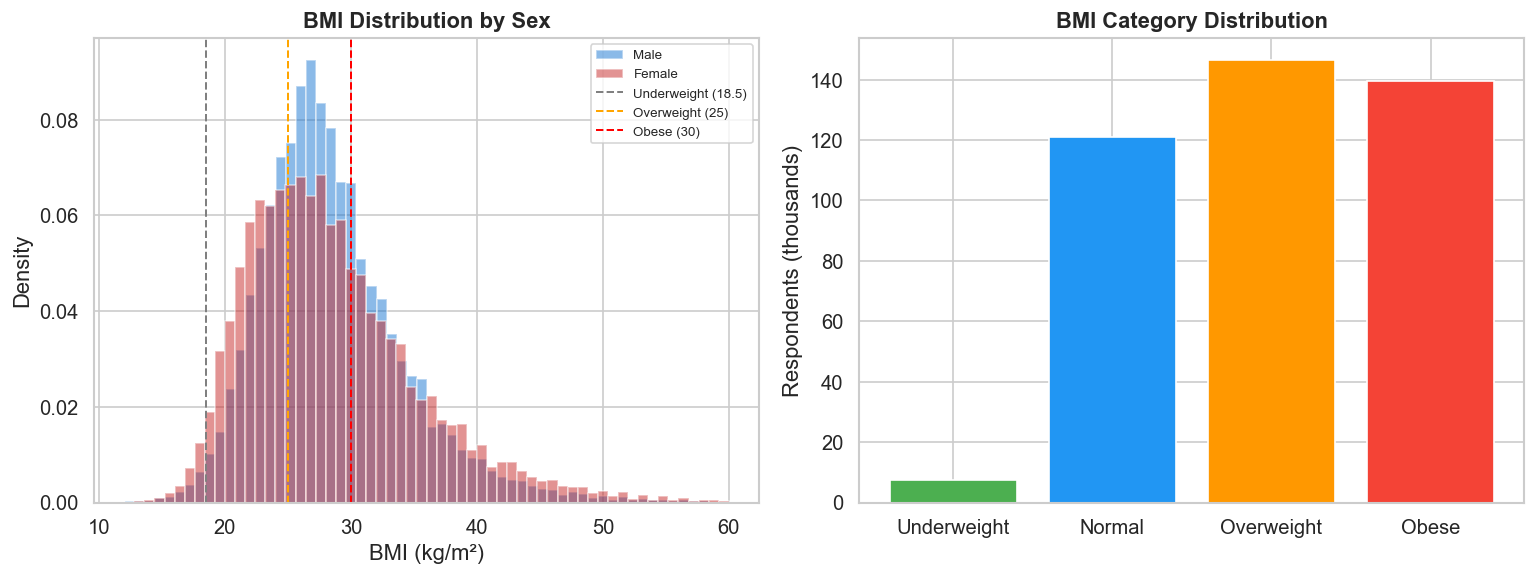

In [12]:
# BMI Distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

bmi_data = df_core[df_core['BMI'].between(12, 60)]

for sex, color in [('Male','#1976D2'), ('Female','#C62828')]:
    sub = bmi_data[bmi_data['SEX_LABEL'] == sex]['BMI']
    axes[0].hist(sub, bins=60, alpha=0.5, color=color, label=sex, density=True)

for cutoff, label, c in [(18.5,'Underweight','gray'),(25,'Overweight','orange'),(30,'Obese','red')]:
    axes[0].axvline(cutoff, color=c, ls='--', lw=1.2, label=f'{label} ({cutoff})')
axes[0].set_title('BMI Distribution by Sex', fontweight='bold')
axes[0].set_xlabel('BMI (kg/m²)')
axes[0].set_ylabel('Density')
axes[0].legend(fontsize=8)

bmi_cat = df_core['BMI_CAT_LABEL'].value_counts().reindex(['Underweight','Normal','Overweight','Obese'])
axes[1].bar(bmi_cat.index, bmi_cat.values / 1000,
            color=['#4CAF50','#2196F3','#FF9800','#F44336'], edgecolor='white')
axes[1].set_title('BMI Category Distribution', fontweight='bold')
axes[1].set_ylabel('Respondents (thousands)')

plt.tight_layout()
plt.show()


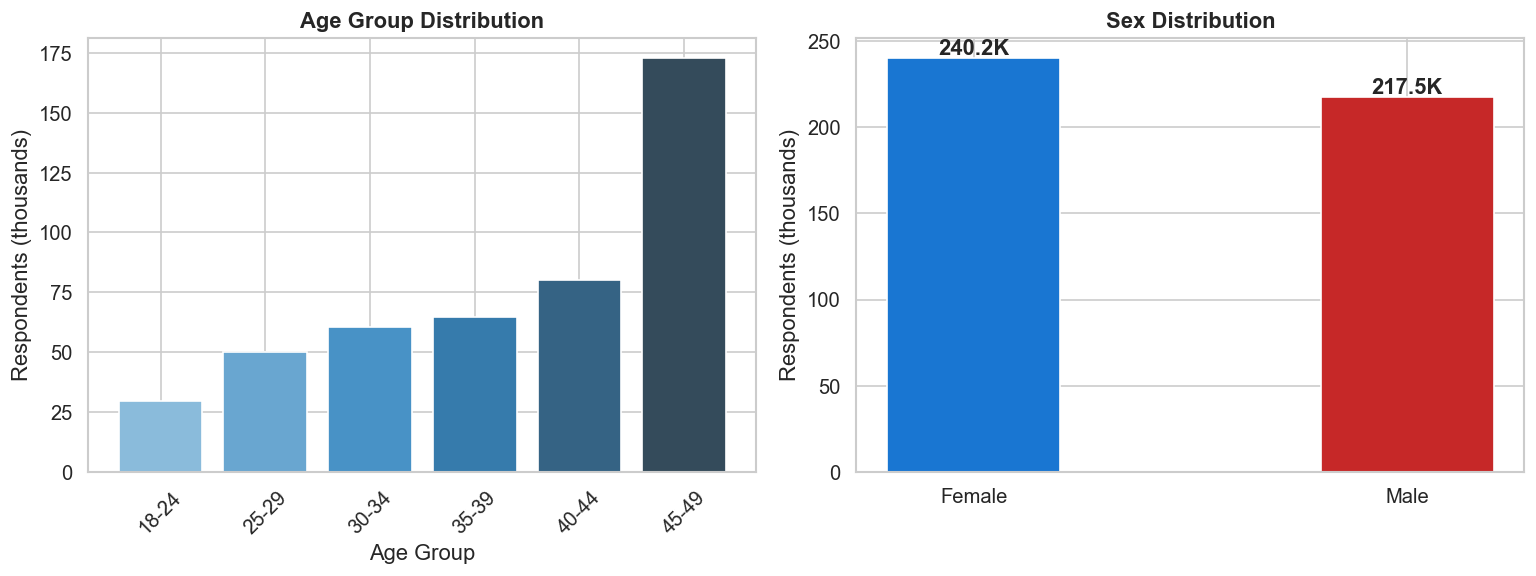

In [13]:
# Age & Sex distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

age_order = ['18-24','25-29','30-34','35-39','40-44','45-49','50-54','55-59','60-64','65-69','70-74','75-79','80+']
age_counts = df_core['AGE_LABEL'].value_counts().reindex([a for a in age_order if a in df_core['AGE_LABEL'].unique()])
axes[0].bar(age_counts.index, age_counts.values / 1000, color=sns.color_palette('Blues_d', len(age_counts)))
axes[0].set_title('Age Group Distribution', fontweight='bold')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Respondents (thousands)')
axes[0].tick_params(axis='x', rotation=45)

sex_counts = df_core['SEX_LABEL'].value_counts()
axes[1].bar(sex_counts.index, sex_counts.values / 1000, color=['#1976D2','#C62828'], width=0.4)
axes[1].set_title('Sex Distribution', fontweight='bold')
axes[1].set_ylabel('Respondents (thousands)')
for i, (idx, val) in enumerate(sex_counts.items()):
    axes[1].text(i, val/1000+2, f'{val/1000:.1f}K', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


## 4. Bivariate Analysis

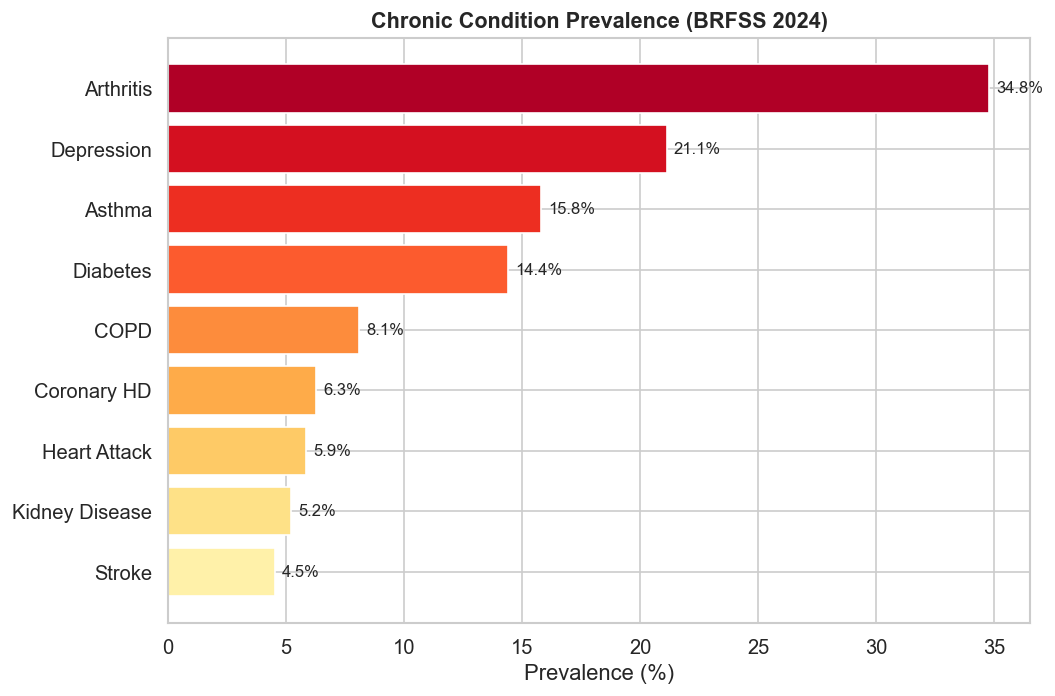

In [14]:
# Chronic Condition Prevalence (BRFSS: 1=Yes, 2=No)
conditions = {
    'Heart Attack': 'CVDINFR4', 'Coronary HD': 'CVDCRHD4', 'Stroke': 'CVDSTRK3',
    'Asthma': 'ASTHMA3', 'COPD': 'CHCCOPD3', 'Depression': 'ADDEPEV3',
    'Kidney Disease': 'CHCKDNY2', 'Arthritis': 'HAVARTH4', 'Diabetes': 'DIABETE4',
}
prev = {}
for label, col in conditions.items():
    if col in df_core.columns:
        prev[label] = (df_core[col] == 1).sum() / df_core[col].notna().sum() * 100

prev_series = pd.Series(prev).sort_values()
fig, ax = plt.subplots(figsize=(9, 6))
colors_cond = sns.color_palette('YlOrRd', len(prev_series))
bars = ax.barh(prev_series.index, prev_series.values, color=colors_cond, edgecolor='white')
for bar, val in zip(bars, prev_series.values):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', va='center', fontsize=10)
ax.set_title('Chronic Condition Prevalence (BRFSS 2024)', fontweight='bold', fontsize=13)
ax.set_xlabel('Prevalence (%)')
plt.tight_layout()
plt.show()


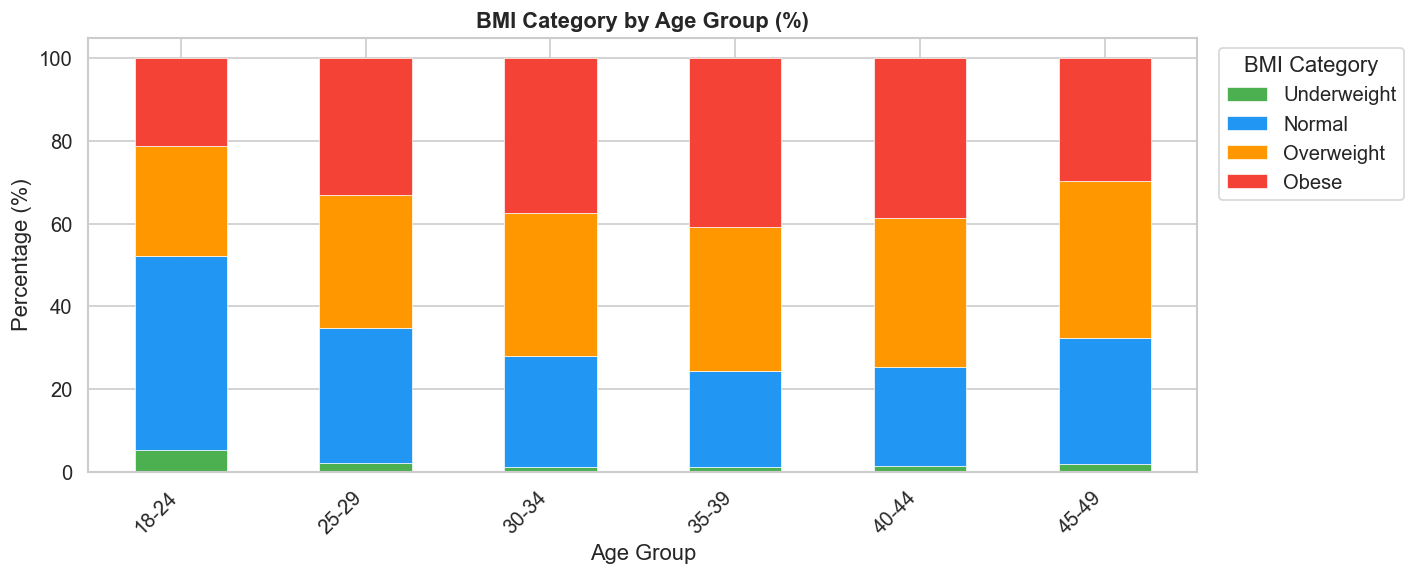

In [15]:
# BMI Category by Age Group (stacked bar)
bmi_age = df_core[df_core['BMI_CAT_LABEL'].notna() & df_core['AGE_LABEL'].notna()]
pivot = bmi_age.groupby(['AGE_LABEL','BMI_CAT_LABEL']).size().unstack(fill_value=0)
age_order = ['18-24','25-29','30-34','35-39','40-44','45-49','50-54','55-59','60-64','65-69','70-74','75-79','80+']
bmi_order = ['Underweight','Normal','Overweight','Obese']
pivot = pivot.reindex(index=[a for a in age_order if a in pivot.index],
                      columns=[b for b in bmi_order if b in pivot.columns])
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 5))
pivot_pct.plot(kind='bar', stacked=True, ax=ax,
               color=['#4CAF50','#2196F3','#FF9800','#F44336'], edgecolor='white', lw=0.4)
ax.set_title('BMI Category by Age Group (%)', fontweight='bold')
ax.set_xlabel('Age Group'); ax.set_ylabel('Percentage (%)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.legend(title='BMI Category', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()


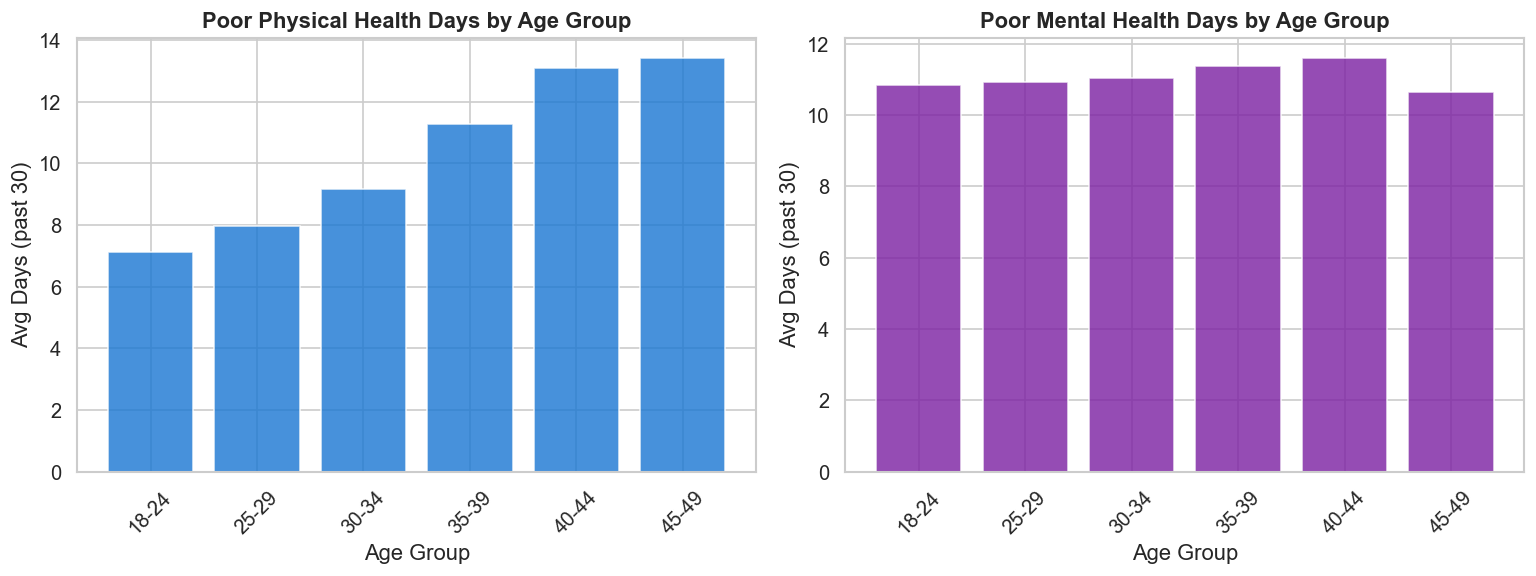

In [16]:
# Health days by Age
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
age_order = ['18-24','25-29','30-34','35-39','40-44','45-49','50-54','55-59','60-64','65-69','70-74','75-79','80+']

for i, (col, title, color) in enumerate(zip(
    ['PHYSHLTH','MENTHLTH'],
    ['Poor Physical Health Days','Poor Mental Health Days'],
    ['#1976D2','#7B1FA2']
)):
    sub = df_core[df_core['AGE_LABEL'].notna() & df_core[col].notna()]
    means = sub.groupby('AGE_LABEL')[col].mean().reindex([a for a in age_order if a in sub['AGE_LABEL'].unique()])
    axes[i].bar(means.index, means.values, color=color, alpha=0.8, edgecolor='white')
    axes[i].set_title(f'{title} by Age Group', fontweight='bold')
    axes[i].set_xlabel('Age Group'); axes[i].set_ylabel('Avg Days (past 30)')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


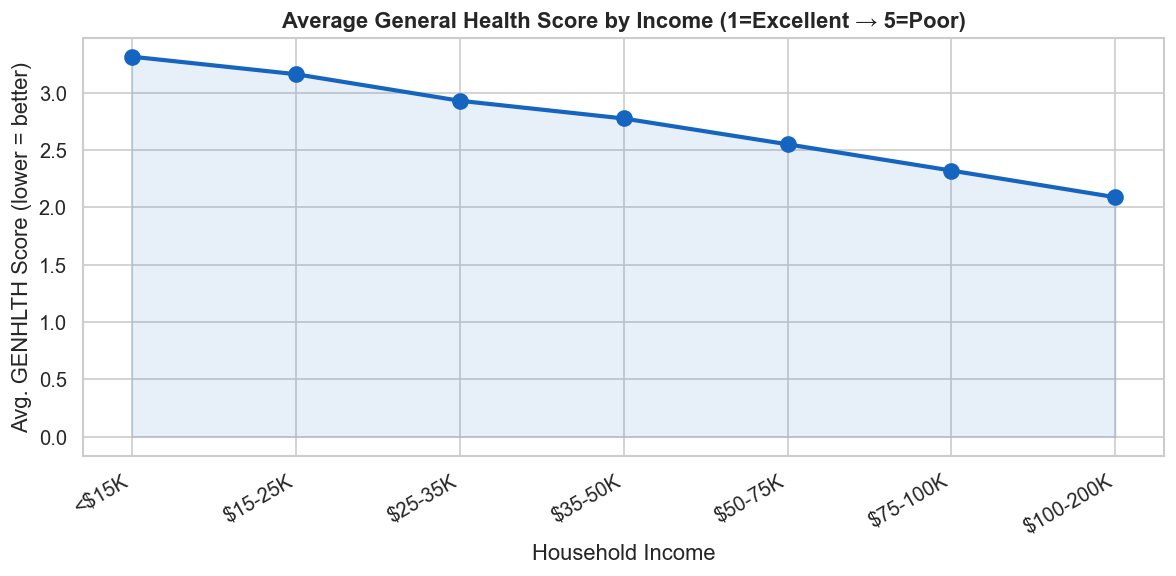

Income range gap (highest-lowest): 1.226


In [17]:
# Income vs General Health
income_order = ['<$15K','$15-25K','$25-35K','$35-50K','$50-75K','$75-100K','$100-200K','>$200K']
gen_by_inc = df_core[df_core['INCOME_LABEL'].notna() & df_core['GENHLTH'].notna()].groupby('INCOME_LABEL')['GENHLTH'].mean()
gen_by_inc = gen_by_inc.reindex([i for i in income_order if i in gen_by_inc.index])

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(gen_by_inc.index, gen_by_inc.values, marker='o', color='#1565C0', lw=2.5, ms=9)
ax.fill_between(range(len(gen_by_inc)), gen_by_inc.values, alpha=0.1, color='#1565C0')
ax.set_xticks(range(len(gen_by_inc)))
ax.set_xticklabels(gen_by_inc.index, rotation=30, ha='right')
ax.set_title('Average General Health Score by Income (1=Excellent → 5=Poor)', fontweight='bold')
ax.set_ylabel('Avg. GENHLTH Score (lower = better)')
ax.set_xlabel('Household Income')
plt.tight_layout()
plt.show()
print("Income range gap (highest-lowest):", round(gen_by_inc.max() - gen_by_inc.min(), 3))


## 5. Correlation Analysis

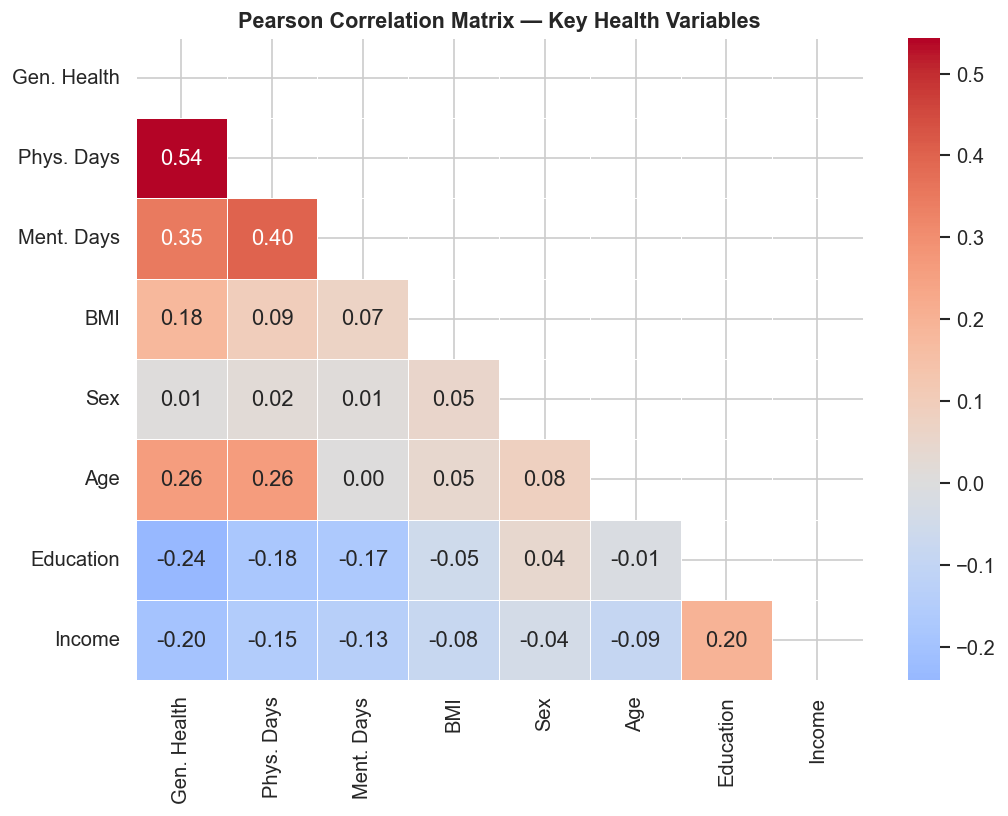

In [18]:
# Pearson Correlation Heatmap
corr_cols = ['GENHLTH','PHYSHLTH','MENTHLTH','BMI','SEXVAR','_AGE_G','_EDUCAG','_INCOMG1']
corr_cols = [c for c in corr_cols if c in df_core.columns]
corr_labels = ['Gen. Health','Phys. Days','Ment. Days','BMI','Sex','Age','Education','Income']

corr_df = df_core[corr_cols].dropna()
corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5,
            xticklabels=corr_labels, yticklabels=corr_labels)
ax.set_title('Pearson Correlation Matrix — Key Health Variables', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()


In [19]:
# Top correlations
corr_pairs = corr_matrix.unstack()
corr_pairs = corr_pairs[corr_pairs < 1.0].drop_duplicates()
print("Top 10 strongest correlations:")
print(corr_pairs.abs().sort_values(ascending=False).head(10).to_string())


Top 10 strongest correlations:
GENHLTH   PHYSHLTH   0.54
PHYSHLTH  MENTHLTH   0.40
GENHLTH   MENTHLTH   0.35
PHYSHLTH  _AGE_G     0.26
GENHLTH   _AGE_G     0.26
          _EDUCAG    0.24
_EDUCAG   _INCOMG1   0.20
GENHLTH   _INCOMG1   0.20
          BMI        0.18
PHYSHLTH  _EDUCAG    0.18


## 6. Save Cleaned Dataset

In [ ]:
# Save cleaned dataset
out_path = 'brfss_cleaned_2024.csv'
df_core.to_csv(out_path, index=False)
print(f"Saved: {out_path}")
print(f"Final shape: {df_core.shape}")
df_core.describe()
